Epoch 1/200
2343/2343 [==============================] - 2s 591us/step - loss: 0.3268 - accuracy: 0.6292
Epoch 2/200
2343/2343 [==============================] - 1s 448us/step - loss: 0.0696 - accuracy: 0.6691
Epoch 3/200
2343/2343 [==============================] - 1s 445us/step - loss: 0.0422 - accuracy: 0.6575
Epoch 4/200
2343/2343 [==============================] - 1s 434us/step - loss: 0.0301 - accuracy: 0.6547
Epoch 5/200
2343/2343 [==============================] - 1s 442us/step - loss: 0.0239 - accuracy: 0.6501
Epoch 6/200
2343/2343 [==============================] - 1s 430us/step - loss: 0.0198 - accuracy: 0.6472
Epoch 7/200
2343/2343 [==============================] - 1s 445us/step - loss: 0.0168 - accuracy: 0.6452
Epoch 8/200
2343/2343 [==============================] - 1s 404us/step - loss: 0.0144 - accuracy: 0.6495
Epoch 9/200
2343/2343 [==============================] - 1s 434us/step - loss: 0.0133 - accuracy: 0.6512
Epoch 10/200
2343/2343 [==============================]

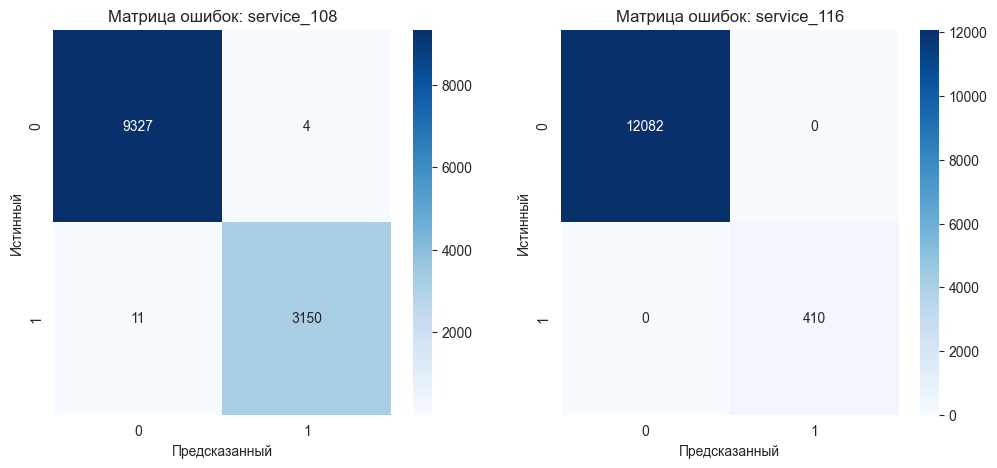

Ошибочные предсказания для service_108


,age,child_number,family_size,income,study_certificate,isEgisso,true_target,pred_target,prob_target
29082,5,1,2,34211,0,0,0,1,0.500455
5141,14,2,3,50738,0,0,1,0,0.484708
21851,0,1,2,34105,0,0,0,1,0.553066
11125,9,3,5,84530,0,0,1,0,0.438532
5453,14,4,5,84781,0,0,1,0,0.391238
47719,15,2,5,84619,0,0,1,0,0.346369
41793,13,1,2,34002,0,0,0,1,0.509254
44097,16,2,4,67771,1,0,1,0,0.286674
23167,9,3,4,67640,0,0,1,0,0.479942
43639,0,4,5,84832,0,0,1,0,0.280771


Ошибочные предсказания для service_116


,age,child_number,family_size,income,study_certificate,isEgisso,true_target,pred_target,prob_target


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Загружаем данные
file_path = '../resources/dataset_108_116.csv'
data = pd.read_csv(file_path).drop(columns=["living_minimum"]).drop_duplicates()

# Определяем признаки и целевые переменные (услуги)
features = ["age", "child_number", "family_size", "income", "study_certificate", "isEgisso"]
service_columns = ["service_108", "service_116"]

X = data[features]
y = data[service_columns]

# Разделяем данные
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Создаем слой нормализации
X_train_array = np.array(X_train, dtype=np.float32)
normalizer = layers.experimental.preprocessing.Normalization()
normalizer.adapt(X_train_array)  # Обучаем нормализатор на тренировочных данных

# Создаем модель с нормализацией внутри
model = keras.Sequential([
    normalizer,  # Встроенная нормализация
    layers.Dense(10, activation='relu'),
    layers.Dense(y_train.shape[1], activation='sigmoid')  # Выходной слой
])

# Компилируем модель
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Обучаем модель
early_stopping = EarlyStopping(monitor='accuracy', patience=100, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=200, batch_size=16, verbose=1, callbacks=[early_stopping])

# Сохраняем модель в файл
model.save("models\\saved_model")

# Прогнозируем
y_pred_prob = model.predict(X_test)  # Получаем вероятности предсказания
y_pred = (y_pred_prob > 0.5).astype(int)  # Бинаризуем предсказания

# Оценка точности по каждой услуге
for i, service in enumerate(service_columns):
    acc = accuracy_score(y_test[service], y_pred[:, i])
    print(f"Точность для {service}: {acc:.10f}")

# Визуализируем матрицы ошибок
fig, axes = plt.subplots(1, len(service_columns), figsize=(6 * len(service_columns), 5))

for i, service in enumerate(service_columns):
    cm = confusion_matrix(y_test[service], y_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=axes[i])
    axes[i].set_title(f"Матрица ошибок: {service}")
    axes[i].set_xlabel("Предсказанный")
    axes[i].set_ylabel("Истинный")

plt.show()

# Анализ ошибок
for i, service in enumerate(service_columns):
    print(f"Ошибочные предсказания для {service}")
    wrong_idx = (y_test[service] != y_pred[:, i])
    errors = X_test[wrong_idx].copy()
    errors["true_target"] = y_test[service][wrong_idx]
    errors["pred_target"] = y_pred[:, i][wrong_idx]
    errors["prob_target"] = y_pred_prob[:, i][wrong_idx]
    display(errors)

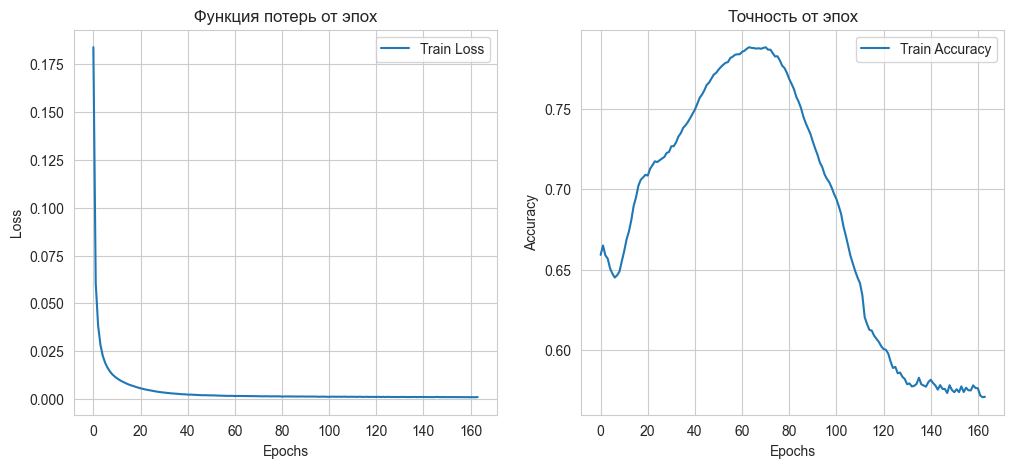

In [2]:
import matplotlib.pyplot as plt

# Графики функции потерь и точности
plt.figure(figsize=(12, 5))

# Потери
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Функция потерь от эпох')
plt.legend()

# Точность
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Точность от эпох')
plt.legend()

plt.show()


In [3]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Финальная точность на тесте: {acc:.4f}")

391/391 [==============================] - 0s 520us/step - loss: 0.0019 - accuracy: 0.7791
Финальная точность на тесте: 0.7791
